Mounted at /content/drive
🔧 Embedding watermark...


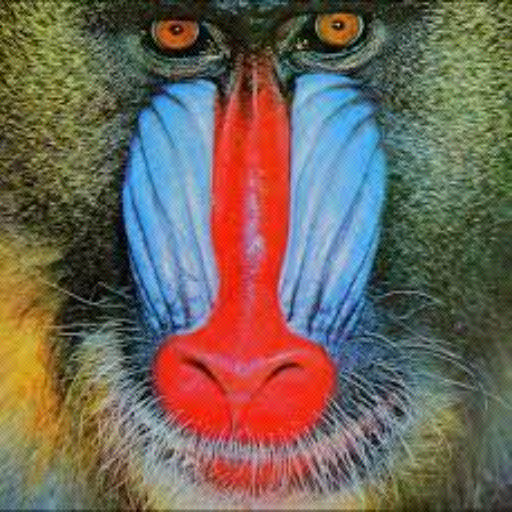

✅ Watermarked image saved to: /content/drive/MyDrive/DIP PROJECT FINAL/watermark_outputs/watermarked_image.png

🔍 Extracting watermark...


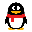

✅ Extracted watermark saved to: /content/drive/MyDrive/DIP PROJECT FINAL/watermark_outputs/extracted_watermark.png

🔹 NC Similarity (Original vs Extracted): 1.0000

🎯 Done.


In [ ]:
#!/usr/bin/env python3
"""
Color Image Watermarking for Google Drive (Colab)
  - Reads host/watermark images from Google Drive
  - Saves outputs (watermarked + extracted) back to Drive
"""

import os
import hashlib
import numpy as np
from scipy.fftpack import dct, idct
from scipy.linalg import hessenberg
from PIL import Image
import pywt
from google.colab import drive
from IPython.display import display

# ----------------------------------
# Connect Google Drive
# ----------------------------------
drive.mount('/content/drive')

# ----------------------------------
# SET YOUR PATHS HERE
# ----------------------------------
# Example:
# host_image_path = "/content/drive/MyDrive/my_images/host.png"
# watermark_image_path = "/content/drive/MyDrive/my_images/logo.png"
# Output folder will be automatically created at: /content/drive/MyDrive/watermark_outputs/

host_image_path = "/content/drive/MyDrive/DIP PROJECT FINAL/host_image.png"       # 👈 Change this
watermark_image_path = "/content/drive/MyDrive/DIP PROJECT FINAL/watermark.png"  # 👈 Change this
output_dir = "/content/drive/MyDrive/DIP PROJECT FINAL/watermark_outputs"
os.makedirs(output_dir, exist_ok=True)

# ----------------------------------
# Helpers
# ----------------------------------
def dct2(block):
    return dct(dct(block.T, norm='ortho').T, norm='ortho')

def idct2(block):
    return idct(idct(block.T, norm='ortho').T, norm='ortho')

# ----------------------------------
# Watermarking Class
# ----------------------------------
class ColorImageWatermarking:
    def __init__(self, strength=30.0, bits_per_block=2, wavelet='haar'):
        self.strength = float(strength)
        self.block_size = 8
        self.bits_per_block = int(bits_per_block)
        self.wavelet = wavelet

    def scramble_watermark_channel(self, wm_channel, key):
        wm = wm_channel.astype(np.float64)
        LL, (LH, HL, HH) = pywt.dwt2(wm, self.wavelet)
        LL_dct = dct2(LL)
        H, Q = hessenberg(LL_dct, calc_q=True)
        U, S, Vt = np.linalg.svd(H, full_matrices=False)
        s_sum = int(np.round(np.sum(np.abs(S)) * 1e6))
        digest = hashlib.md5(f"{key}_{s_sum}".encode()).hexdigest()
        seed = int(digest[:8], 16)
        total = wm.size
        rng = np.random.RandomState(seed)
        perm = rng.permutation(total)
        flat = wm.flatten()
        scrambled_flat = flat[perm]
        scrambled = scrambled_flat.reshape(wm.shape).astype(np.uint8)
        return scrambled, perm

    def descramble_watermark_channel(self, scrambled_channel, perm):
        flat = scrambled_channel.flatten()
        restored_flat = np.zeros_like(flat)
        restored_flat[perm] = flat
        return restored_flat.reshape(scrambled_channel.shape).astype(np.uint8)

    def generate_sequence(self, key, length):
        h = hashlib.md5(str(key).encode()).hexdigest()
        seed = int(h[:8], 16)
        rng = np.random.RandomState(seed)
        return rng.permutation(length)

    def embed_watermark(self, host_image_path, watermark_image_path, key=12345):
        host = Image.open(host_image_path).convert('RGB')
        watermark = Image.open(watermark_image_path)

        if watermark.mode == 'RGBA':
            watermark = watermark.convert('RGB')

        if watermark.size != (32, 32):
            watermark = watermark.resize((32, 32), Image.LANCZOS)

        host_arr = np.array(host, dtype=np.float64)
        wm_arr = np.array(watermark, dtype=np.uint8)
        host_h, host_w = host_arr.shape[:2]
        wm_h, wm_w = wm_arr.shape[:2]

        available_blocks = (host_h // self.block_size) * (host_w // self.block_size)
        bits_needed = wm_h * wm_w * 8
        available_bits = available_blocks * self.bits_per_block

        if bits_needed > available_bits:
            self.bits_per_block = int(np.ceil(bits_needed / available_blocks))

        with open("watermark_info.txt", "w") as f:
            f.write(f"{wm_h},{wm_w},{self.bits_per_block}")

        watermarked_channels = []
        for ch in range(3):
            host_ch = host_arr[:, :, ch].copy()
            wm_ch = wm_arr[:, :, ch]
            scrambled_ch, perm = self.scramble_watermark_channel(wm_ch, key + ch)
            np.save(f"perm_channel_{ch}.npy", perm)

            wm_bits = np.unpackbits(scrambled_ch.flatten())
            total_bits = len(wm_bits)
            h, w = host_ch.shape
            num_blocks_h = h // self.block_size
            num_blocks_w = w // self.block_size
            total_blocks = num_blocks_h * num_blocks_w
            sequence = self.generate_sequence(key + ch, total_blocks)
            blocks_needed = int(np.ceil(total_bits / self.bits_per_block))

            positions = [(3, 3), (3, 4), (4, 3), (4, 4)]
            watermarked_ch = host_ch.copy()
            bit_idx = 0

            for b in range(blocks_needed):
                block_num = sequence[b]
                br = block_num // num_blocks_w
                bc = block_num % num_blocks_w
                r0 = br * self.block_size
                c0 = bc * self.block_size
                block = host_ch[r0:r0+8, c0:c0+8].copy()
                d = dct2(block)
                for p in range(self.bits_per_block):
                    if bit_idx >= total_bits:
                        break
                    bit = wm_bits[bit_idx]
                    pos = positions[p % len(positions)]
                    mag = abs(d[pos])
                    d[pos] = mag + self.strength if bit == 1 else -(mag + self.strength)
                    bit_idx += 1
                watermarked_ch[r0:r0+8, c0:c0+8] = idct2(d)

            watermarked_channels.append(np.clip(watermarked_ch, 0, 255).astype(np.uint8))
        return Image.fromarray(np.stack(watermarked_channels, axis=2))

    def extract_watermark(self, wm_image_path, watermark_size=(32, 32), key=12345):
        wm_image = Image.open(wm_image_path).convert('RGB')
        w_arr = np.array(wm_image, dtype=np.float64)
        try:
            with open("watermark_info.txt", "r") as f:
                parts = f.read().split(',')
                wm_h = int(parts[0]); wm_w = int(parts[1]); self.bits_per_block = int(parts[2])
        except:
            wm_h, wm_w = watermark_size

        extracted_channels = []
        for ch in range(3):
            wm_ch = w_arr[:, :, ch]
            num_bits = wm_h * wm_w * 8
            h, w = wm_ch.shape
            num_blocks_h = h // 8
            num_blocks_w = w // 8
            total_blocks = num_blocks_h * num_blocks_w
            sequence = self.generate_sequence(key + ch, total_blocks)
            blocks_needed = int(np.ceil(num_bits / self.bits_per_block))
            positions = [(3, 3), (3, 4), (4, 3), (4, 4)]
            bits = []
            for b in range(blocks_needed):
                block_num = sequence[b]
                br = block_num // num_blocks_w
                bc = block_num % num_blocks_w
                r0 = br * 8
                c0 = bc * 8
                block = wm_ch[r0:r0+8, c0:c0+8]
                d = dct2(block)
                for p in range(self.bits_per_block):
                    if len(bits) >= num_bits: break
                    coef = d[positions[p]]
                    bits.append(1 if coef > 0 else 0)
            bits = np.array(bits[:num_bits], dtype=np.uint8)
            scrambled = np.packbits(bits).reshape((wm_h, wm_w))
            perm_file = f"perm_channel_{ch}.npy"
            if os.path.exists(perm_file):
                perm = np.load(perm_file)
                restored = self.descramble_watermark_channel(scrambled, perm)
            else:
                restored = scrambled
            extracted_channels.append(restored.astype(np.uint8))
        return Image.fromarray(np.stack(extracted_channels, axis=2))

# ======================================
# NC Similarity
# ======================================
def calculate_nc(img1, img2):
    a = np.array(img1, dtype=np.float64)
    b = np.array(img2, dtype=np.float64)
    num = np.sum(a * b)
    den = np.sqrt(np.sum(a * a) * np.sum(b * b))
    return num / den if den != 0 else 0

# ======================================
# EXECUTION FLOW
# ======================================
SECRET_KEY = 12345
wmkr = ColorImageWatermarking()

print("🔧 Embedding watermark...")
watermarked = wmkr.embed_watermark(host_image_path, watermark_image_path, key=SECRET_KEY)
wm_output_path = os.path.join(output_dir, "watermarked_image.png")
watermarked.save(wm_output_path, quality=100)
display(watermarked)
print(f"✅ Watermarked image saved to: {wm_output_path}")

print("\n🔍 Extracting watermark...")
extracted = wmkr.extract_watermark(wm_output_path, (32, 32), key=SECRET_KEY)
extract_output_path = os.path.join(output_dir, "extracted_watermark.png")
extracted.save(extract_output_path)
display(extracted)
print(f"✅ Extracted watermark saved to: {extract_output_path}")

original = Image.open(watermark_image_path).convert("RGB").resize((32, 32))
nc = calculate_nc(original, extracted)
print(f"\n🔹 NC Similarity (Original vs Extracted): {nc:.4f}")
print("\n🎯 Done.")


🖼️ Showing input images...


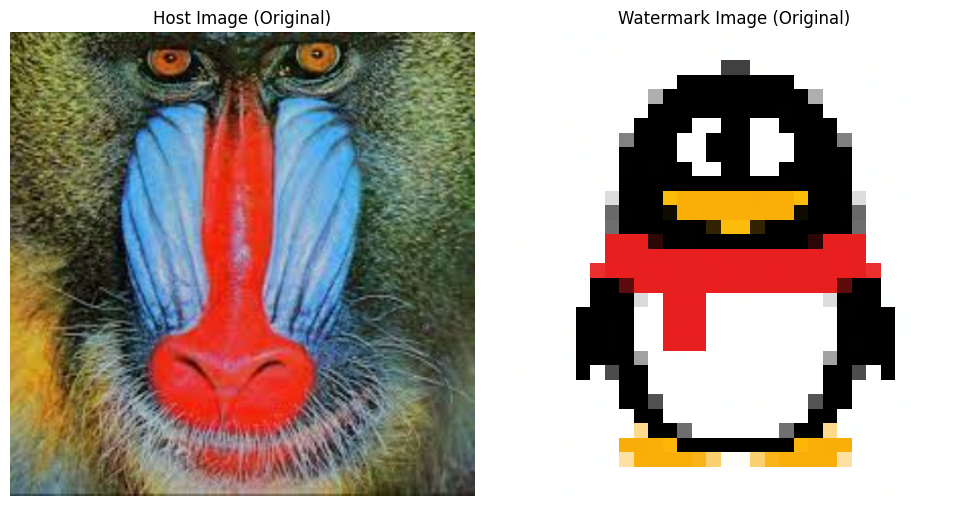

🔧 Embedding watermark...
✅ Watermarked image saved to: /content/drive/MyDrive/DIP PROJECT FINAL/watermark_outputs/watermarked_image.png
🔍 Comparing Host vs Watermarked Image...


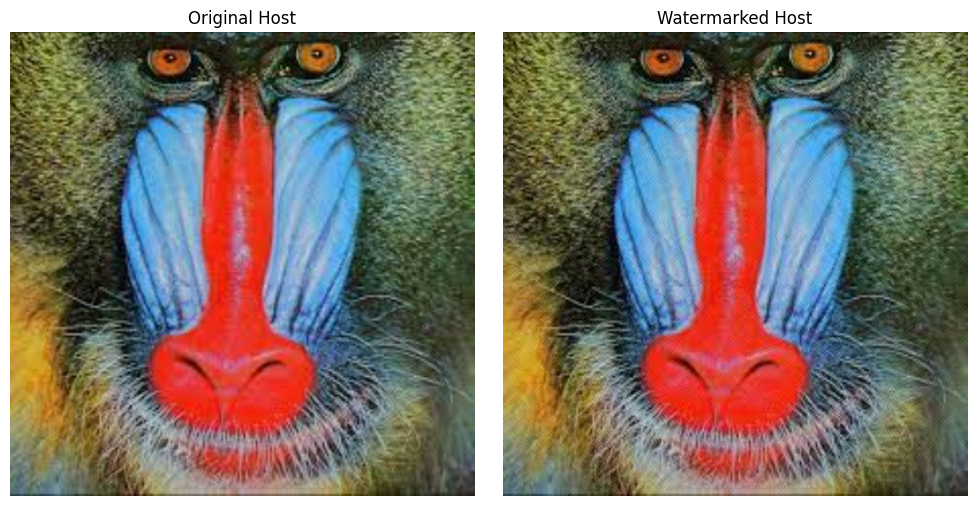


🔍 Extracting watermark...
✅ Extracted watermark saved to: /content/drive/MyDrive/DIP PROJECT FINAL/watermark_outputs/extracted_watermark.png
📊 Comparing Original vs Extracted Watermark...


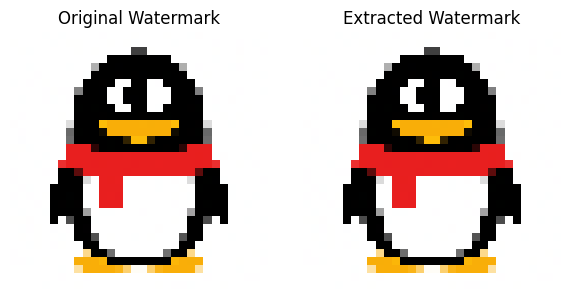


🔹 NC Similarity (Original vs Extracted): 1.0000

🎯 Done.


In [ ]:
# ======================================
# EXECUTION FLOW (with comparisons)
# ======================================
import matplotlib.pyplot as plt

SECRET_KEY = 12345
wmkr = ColorImageWatermarking()

# -------------------------------
# STEP 1: Display Input Images
# -------------------------------
print("🖼️ Showing input images...")

host_img = Image.open(host_image_path).convert("RGB")
watermark_img = Image.open(watermark_image_path).convert("RGB").resize((32, 32))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(host_img)
axes[0].set_title("Host Image (Original)")
axes[0].axis("off")

axes[1].imshow(watermark_img)
axes[1].set_title("Watermark Image (Original)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

# -------------------------------
# STEP 2: Embed Watermark
# -------------------------------
print("🔧 Embedding watermark...")
watermarked = wmkr.embed_watermark(host_image_path, watermark_image_path, key=SECRET_KEY)
wm_output_path = os.path.join(output_dir, "watermarked_image.png")
watermarked.save(wm_output_path, quality=100)
print(f"✅ Watermarked image saved to: {wm_output_path}")

# -------------------------------
# STEP 3: Compare Host vs Watermarked
# -------------------------------
print("🔍 Comparing Host vs Watermarked Image...")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(host_img)
axes[0].set_title("Original Host")
axes[0].axis("off")

axes[1].imshow(watermarked)
axes[1].set_title("Watermarked Host")
axes[1].axis("off")

plt.tight_layout()
plt.show()

# -------------------------------
# STEP 4: Extract Watermark
# -------------------------------
print("\n🔍 Extracting watermark...")
extracted = wmkr.extract_watermark(wm_output_path, (32, 32), key=SECRET_KEY)
extract_output_path = os.path.join(output_dir, "extracted_watermark.png")
extracted.save(extract_output_path)
print(f"✅ Extracted watermark saved to: {extract_output_path}")

# -------------------------------
# STEP 5: Compare Watermarks
# -------------------------------
print("📊 Comparing Original vs Extracted Watermark...")

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(watermark_img)
axes[0].set_title("Original Watermark")
axes[0].axis("off")

axes[1].imshow(extracted)
axes[1].set_title("Extracted Watermark")
axes[1].axis("off")

plt.tight_layout()
plt.show()

# -------------------------------
# STEP 6: Similarity Check
# -------------------------------
original_resized = watermark_img.resize((32, 32))
nc = calculate_nc(original_resized, extracted)
print(f"\n🔹 NC Similarity (Original vs Extracted): {nc:.4f}")

print("\n🎯 Done.")


In [ ]:
# Colab-ready cell — paste this into Google Colab and run.
# It mounts Google Drive, uses your specified host/watermark paths,
# and saves outputs into a Drive folder.

from google.colab import drive
drive.mount('/content/drive')

# --- start of your original script, minimally adapted for Colab Drive paths ---
#!/usr/bin/env python3
"""
Interactive watermarking + attacks script.

Run in Colab: paste the whole cell and run. You will be prompted to choose attacks
(or press Enter to use the default selection).
"""

import os
import sys
import hashlib
import numpy as np
from scipy.fftpack import dct, idct
from scipy.linalg import hessenberg
from PIL import Image, ImageFilter
import pywt

# ---------------------------
# Small helpers
# ---------------------------
def dct2(block):
    return dct(dct(block.T, norm='ortho').T, norm='ortho')

def idct2(block):
    return idct(idct(block.T, norm='ortho').T, norm='ortho')

# ---------------------------
# Watermarker class
# ---------------------------
class ColorImageWatermarking:
    def __init__(self, strength=30.0, bits_per_block=2, wavelet='haar', output_dir='/content/drive/MyDrive/DIP PROJECT FINAL/outputs'):
        self.strength = float(strength)
        self.block_size = 8
        self.bits_per_block = int(bits_per_block)
        self.wavelet = wavelet
        self.output_dir = output_dir

    def scramble_watermark_channel(self, wm_channel, key):
        wm = wm_channel.astype(np.float64)
        LL, (LH, HL, HH) = pywt.dwt2(wm, self.wavelet)
        LL_dct = dct2(LL)
        H, Q = hessenberg(LL_dct, calc_q=True)
        U, S, Vt = np.linalg.svd(H, full_matrices=False)
        s_sum = int(np.round(np.sum(np.abs(S)) * 1e6))
        digest = hashlib.md5(f"{key}_{s_sum}".encode()).hexdigest()
        seed = int(digest[:8], 16)
        total = wm.size
        rng = np.random.RandomState(seed)
        perm = rng.permutation(total)
        flat = wm.flatten()
        scrambled_flat = flat[perm]
        scrambled = scrambled_flat.reshape(wm.shape).astype(np.uint8)
        return scrambled, perm

    def descramble_watermark_channel(self, scrambled_channel, perm):
        flat = scrambled_channel.flatten()
        total = flat.size
        restored_flat = np.zeros_like(flat)
        restored_flat[perm] = flat
        restored = restored_flat.reshape(scrambled_channel.shape).astype(np.uint8)
        return restored

    def generate_sequence(self, key, length):
        h = hashlib.md5(str(key).encode()).hexdigest()
        seed = int(h[:8], 16)
        rng = np.random.RandomState(seed)
        return rng.permutation(length)

    def embed_watermark(self, host_image_path, watermark_image_path, key=12345):
        print("=" * 70)
        print("WATERMARK EMBEDDING (DWT+DCT+Hessenberg+SVD scramble + DCT embedding)")
        print("=" * 70)

        host = Image.open(host_image_path).convert('RGB')
        watermark = Image.open(watermark_image_path)
        if watermark.mode == 'RGBA':
            bg = Image.new('RGB', watermark.size, (255,255,255))
            bg.paste(watermark, mask=watermark.split()[3])
            watermark = bg
        else:
            watermark = watermark.convert('RGB')

        if watermark.size != (32, 32):
            print(f"Resizing watermark {watermark.size} -> (32,32)")
            watermark = watermark.resize((32,32), Image.LANCZOS)

        host_arr = np.array(host, dtype=np.float64)
        wm_arr = np.array(watermark, dtype=np.uint8)
        host_h, host_w = host_arr.shape[:2]
        wm_h, wm_w = wm_arr.shape[:2]

        available_blocks = (host_h // self.block_size) * (host_w // self.block_size)
        bits_needed_per_channel = wm_h * wm_w * 8
        available_bits = available_blocks * self.bits_per_block

        print(f"Host: {host_h}x{host_w}, Watermark: {wm_h}x{wm_w}")
        print(f"Available blocks: {available_blocks}, bits_per_block: {self.bits_per_block}, available_bits: {available_bits}")
        print(f"Bits needed per channel: {bits_needed_per_channel}")

        if bits_needed_per_channel > available_bits:
            print("⚠ Not enough capacity. Increasing bits_per_block automatically.")
            self.bits_per_block = int(np.ceil(bits_needed_per_channel / available_blocks))
            available_bits = available_blocks * self.bits_per_block
            print(f"New bits_per_block: {self.bits_per_block} (available_bits={available_bits})")
        else:
            print("✓ Sufficient capacity")

        wm_info_path = os.path.join(self.output_dir, 'watermark_info.txt')
        with open(wm_info_path, 'w') as f:
            f.write(f"{wm_h},{wm_w},{self.bits_per_block}")

        watermarked_channels = []

        for ch in range(3):
            print(f"\nProcessing channel {ch+1}/3 ...")
            host_ch = host_arr[:,:,ch].copy()
            wm_ch = wm_arr[:,:,ch]
            print("  - Scrambling watermark channel (DWT+DCT+Hessenberg+SVD)...")
            scrambled_ch, perm = self.scramble_watermark_channel(wm_ch, key + ch)
            perm_path = os.path.join(self.output_dir, f'perm_channel_{ch}.npy')
            np.save(perm_path, perm)
            wm_bits = np.unpackbits(scrambled_ch.flatten())
            total_bits = len(wm_bits)
            print(f"  - Bits to embed: {total_bits}")
            h, w = host_ch.shape
            num_blocks_h = h // self.block_size
            num_blocks_w = w // self.block_size
            total_blocks = num_blocks_h * num_blocks_w
            sequence = self.generate_sequence(key + ch, total_blocks)
            blocks_needed = int(np.ceil(total_bits / self.bits_per_block))
            print(f"  - Blocks needed: {blocks_needed}/{total_blocks}")
            positions = [(3,3), (3,4), (4,3), (4,4)]
            watermarked_ch = host_ch.copy()
            bit_idx = 0

            for b in range(blocks_needed):
                if b >= len(sequence):
                    break
                block_num = sequence[b]
                br = block_num // num_blocks_w
                bc = block_num % num_blocks_w
                r0 = br * self.block_size
                c0 = bc * self.block_size
                block = host_ch[r0:r0+self.block_size, c0:c0+self.block_size].copy()
                d = dct2(block)

                for pidx in range(self.bits_per_block):
                    if bit_idx >= total_bits:
                        break
                    bit = int(wm_bits[bit_idx])
                    pos = positions[pidx % len(positions)]
                    mag = abs(d[pos])
                    if bit == 1:
                        d[pos] = mag + self.strength
                    else:
                        d[pos] = -(mag + self.strength)
                    bit_idx += 1

                modified_block = idct2(d)
                watermarked_ch[r0:r0+self.block_size, c0:c0+self.block_size] = modified_block

                if (b+1) % 500 == 0:
                    print(f"    Progress: {bit_idx}/{total_bits} bits embedded")

            print(f"  ✓ Embedded {bit_idx}/{total_bits} bits")
            watermarked_ch = np.clip(watermarked_ch, 0, 255).astype(np.uint8)
            watermarked_channels.append(watermarked_ch)

        watermarked_img = np.stack(watermarked_channels, axis=2)
        print("\n✓ EMBEDDING COMPLETED")
        return Image.fromarray(watermarked_img)

    def extract_watermark(self, watermarked_image_path, watermark_size=(32,32), key=12345):
        print("=" * 70)
        print("WATERMARK EXTRACTION (DCT extraction + inverse perm descramble)")
        print("=" * 70)

        watermarked = Image.open(watermarked_image_path).convert('RGB')
        w_arr = np.array(watermarked, dtype=np.float64)

        wm_info_path = os.path.join(self.output_dir, 'watermark_info.txt')
        try:
            with open(wm_info_path, 'r') as f:
                parts = f.read().strip().split(',')
                wm_h = int(parts[0]); wm_w = int(parts[1]); bpb = int(parts[2])
                self.bits_per_block = bpb
                print(f"Loaded watermark info: size=({wm_h},{wm_w}), bits_per_block={bpb}")
        except Exception:
            wm_h, wm_w = watermark_size
            print("Warning: watermark_info.txt not found in outputs, using provided watermark_size and default bits_per_block")

        extracted_channels = []

        for ch in range(3):
            print(f"\nProcessing channel {ch+1}/3 for extraction ...")
            wm_ch_img = w_arr[:,:,ch]
            num_bits = wm_h * wm_w * 8
            print(f"  - Need to extract {num_bits} bits")
            h, w = wm_ch_img.shape
            num_blocks_h = h // self.block_size
            num_blocks_w = w // self.block_size
            total_blocks = num_blocks_h * num_blocks_w
            sequence = self.generate_sequence(key + ch, total_blocks)
            blocks_needed = int(np.ceil(num_bits / self.bits_per_block))
            print(f"  - Extracting from {blocks_needed} blocks")
            positions = [(3,3), (3,4), (4,3), (4,4)]
            extracted_bits = []

            for b in range(blocks_needed):
                if b >= len(sequence):
                    break
                block_num = sequence[b]
                br = block_num // num_blocks_w
                bc = block_num % num_blocks_w
                r0 = br * self.block_size
                c0 = bc * self.block_size
                block = wm_ch_img[r0:r0+self.block_size, c0:c0+self.block_size]
                d = dct2(block)

                for pidx in range(self.bits_per_block):
                    if len(extracted_bits) >= num_bits:
                        break
                    pos = positions[pidx % len(positions)]
                    coef = d[pos]
                    extracted_bits.append(1 if coef > 0 else 0)

                if (b+1) % 500 == 0:
                    print(f"    Progress: {len(extracted_bits)}/{num_bits} bits extracted")

            if len(extracted_bits) < num_bits:
                extracted_bits.extend([0] * (num_bits - len(extracted_bits)))
            extracted_bits = extracted_bits[:num_bits]

            bits_arr = np.array(extracted_bits, dtype=np.uint8)
            bytes_arr = np.packbits(bits_arr)
            scrambled_ch = bytes_arr.reshape((wm_h, wm_w))

            perm_file = os.path.join(self.output_dir, f'perm_channel_{ch}.npy')
            if os.path.exists(perm_file):
                perm = np.load(perm_file)
                restored_ch = self.descramble_watermark_channel(scrambled_ch, perm)
                print("  - Restored by inverse permutation (perm file loaded)")
            else:
                print("  - perm file missing; returning scrambled channel as-is")
                restored_ch = scrambled_ch

            extracted_channels.append(restored_ch.astype(np.uint8))

        extracted_wm = np.stack(extracted_channels, axis=2)
        print("\n✓ EXTRACTION COMPLETED")
        return Image.fromarray(extracted_wm.astype(np.uint8))

# ---------------------------
# Noise / Attack functions
# ---------------------------
def add_gaussian_noise(pil_img, sigma=10):
    arr = np.array(pil_img).astype(np.float32)
    noise = np.random.normal(0, sigma, arr.shape)
    noisy = arr + noise
    noisy = np.clip(noisy, 0, 255).astype(np.uint8)
    return Image.fromarray(noisy)


def add_poisson_noise(pil_img):
    arr = np.array(pil_img).astype(np.float32)
    vals = len(np.unique(arr.flatten()))
    vals = 2 ** np.ceil(np.log2(vals))
    noisy = np.random.poisson(arr / 255.0 * vals) / float(vals) * 255.0
    noisy = np.clip(noisy, 0, 255).astype(np.uint8)
    return Image.fromarray(noisy)




def add_sharpen(pil_img):
    return pil_img.filter(ImageFilter.UnsharpMask(radius=1, percent=150, threshold=3))



def add_resizing_attack(pil_img, scale_down=0.5):
    w, h = pil_img.size
    small = pil_img.resize((max(1,int(w*scale_down)), max(1,int(h*scale_down))), Image.LANCZOS)
    back = small.resize((w,h), Image.LANCZOS)
    return back


    return back

# ---------------------------
# Quality metrics
# ---------------------------
def calculate_psnr_from_arrays(arr1, arr2):
    import math
    i1 = arr1.astype(np.float64)
    i2 = arr2.astype(np.float64)
    mse = np.mean((i1 - i2) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * math.log10(255.0 / math.sqrt(mse))

def calculate_nc(img_arr_a, img_arr_b):
    a = img_arr_a.astype(np.float64).flatten()
    b = img_arr_b.astype(np.float64).flatten()
    num = np.sum(a * b)
    den = np.sqrt(np.sum(a**2) * np.sum(b**2))
    return (num / den) if den != 0 else 0

# ---------------------------
# Interactive menu
# ---------------------------
ATTACKS_MENU = {
    1: ("Gaussian Noise", lambda img: add_gaussian_noise(img, sigma=12), "gaussian_noise.png"),


    2: ("Poisson Noise", lambda img: add_poisson_noise(img), "poisson_noise.png"),


    3: (" Unsharp Mask", lambda img: add_sharpen(img), "sharpen.png"),


    4: ("Resize Down/Up (0.5)", lambda img: add_resizing_attack(img, scale_down=0.5), "resized_back.png"),
}

def prompt_user_for_attacks():
    print("\nChoose attacks to apply to the watermarked image.")
    print("Enter numbers separated by spaces or commas. Example: 1 2 5 6")
    print("You may choose up to 4 attacks .")
    print("\nAvailable attacks:")
    for k, (name, _, _) in ATTACKS_MENU.items():
        print(f"  {k:2d}. {name}")
    raw = input("\nEnter attack numbers : ").strip()
    if raw == "":
        return [1,2,5,6]
    parts = [p.strip() for p in raw.replace(',', ' ').split()]
    choices = []
    for p in parts:
        try:
            n = int(p)
            if n in ATTACKS_MENU:
                if n not in choices:
                    choices.append(n)
            else:
                print(f"Ignoring invalid choice: {p}")
        except ValueError:
            print(f"Ignoring invalid token: {p}")
    if not choices:
        print("No valid choices selected. Using default [1,2,5,6].")
        return [1,2,5,6]
    return choices

# ---------------------------
# MAIN
# ---------------------------
def main():
    print("\nCOLOR IMAGE WATERMARKING (DWT + DCT + Hessenberg + SVD) + INTERACTIVE ATTACKS")

    # --- Set your Drive paths here (user requested) ---
    HOST_IMAGE_PATH = "/content/drive/MyDrive/DIP PROJECT FINAL/host_image.png"
    WATERMARK_IMAGE_PATH = "/content/drive/MyDrive/DIP PROJECT FINAL/watermark.png"
    OUTPUT_DIR = "/content/drive/MyDrive/DIP PROJECT FINAL/outputs"

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    # initialize with output_dir so class can save perms/info into Drive
    wmkr = ColorImageWatermarking(strength=30.0, bits_per_block=2, wavelet='haar', output_dir=OUTPUT_DIR)
    SECRET_KEY = 12345

    if not os.path.exists(HOST_IMAGE_PATH) or not os.path.exists(WATERMARK_IMAGE_PATH):
        print("❌ ERROR: Put host_image.png and watermark.png at the following paths in your Drive:")
        print(f"  Host image: {HOST_IMAGE_PATH}")
        print(f"  Watermark:  {WATERMARK_IMAGE_PATH}")
        return

    # Ask user for attacks
    choices = prompt_user_for_attacks()
    print(f"\nSelected attacks: {choices}")

    # Embedding
    print("\nSTEP 1: EMBEDDING")
    watermarked_img = wmkr.embed_watermark(HOST_IMAGE_PATH, WATERMARK_IMAGE_PATH, key=SECRET_KEY)
    base_wm_path = os.path.join(OUTPUT_DIR, 'watermarked_image.png')
    # save to Drive
    watermarked_img.save(base_wm_path, quality=100, subsampling=0)
    print(f"Saved: {base_wm_path}")

    host_arr = np.array(Image.open(HOST_IMAGE_PATH).convert('RGB'), dtype=np.uint8)

    # Apply chosen attacks
    for idx in choices:
        if idx not in ATTACKS_MENU:
            continue
        name, fn, out_name = ATTACKS_MENU[idx]
        out_path = os.path.join(OUTPUT_DIR, out_name)
        print("\n" + "="*60)
        print(f"ATTACK {idx}: {name}")
        print("="*60)

        # For JPEG attack we pass output_dir-aware function
        if idx == 5:
            noisy = add_jpeg_compression(watermarked_img, quality=30, output_dir=OUTPUT_DIR)
        else:
            noisy = fn(watermarked_img)

        noisy.save(out_path)
        print(f"Saved noisy image: {out_path}")

        noisy_arr = np.array(noisy.convert('RGB'), dtype=np.uint8)
        if host_arr.shape != noisy_arr.shape:
            noisy = noisy.resize((host_arr.shape[1], host_arr.shape[0]), Image.LANCZOS)
            noisy_arr = np.array(noisy, dtype=np.uint8)

        psnr_val = calculate_psnr_from_arrays(host_arr, noisy_arr)
        print(f"PSNR (host vs noisy_watermarked): {psnr_val:.2f} dB")

        # Extract watermark from noisy image file path
        extracted = wmkr.extract_watermark(out_path, watermark_size=(32,32), key=SECRET_KEY)
        extracted_name = f"extracted_attack_{idx}.png"
        extracted_path = os.path.join(OUTPUT_DIR, extracted_name)
        extracted.save(extracted_path)
        print(f"Saved extracted watermark: {extracted_path}")

        # Compute NC between original watermark and extracted
        try:
            orig_wm_arr = np.array(Image.open(WATERMARK_IMAGE_PATH).convert('RGB'), dtype=np.uint8)
            if orig_wm_arr.shape[:2] != (32,32):
                orig_wm_arr = np.array(Image.open(WATERMARK_IMAGE_PATH).convert('RGB').resize((32,32), Image.LANCZOS), dtype=np.uint8)
            ext_arr = np.array(Image.open(extracted_path).convert('RGB'), dtype=np.uint8)
            nc_val = calculate_nc(orig_wm_arr, ext_arr)
            print(f"NC (original watermark vs extracted after '{name}'): {nc_val:.4f}")
        except Exception as e:
            print("Could not compute NC:", e)

    print("\nALL SELECTED ATTACKS PROCESSED. Check output images and extracted_attack_*.png files in:")
    print(f"  {OUTPUT_DIR}")
    print("You can re-run the script and choose different attacks or adjust embedding strength/bits_per_block in the code.")

if __name__ == "__main__":
    main()
# --- end of adapted script ---


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

COLOR IMAGE WATERMARKING (DWT + DCT + Hessenberg + SVD) + INTERACTIVE ATTACKS

Choose attacks to apply to the watermarked image.
Enter numbers separated by spaces or commas. Example: 1 2 5 6
You may choose up to 4 attacks .

Available attacks:
   1. Gaussian Noise
   2. Poisson Noise
   3.  Unsharp Mask
   4. Resize Down/Up (0.5)

Enter attack numbers : 1 2 3 4

Selected attacks: [1, 2, 3, 4]

STEP 1: EMBEDDING
WATERMARK EMBEDDING (DWT+DCT+Hessenberg+SVD scramble + DCT embedding)
Host: 512x512, Watermark: 32x32
Available blocks: 4096, bits_per_block: 2, available_bits: 8192
Bits needed per channel: 8192
✓ Sufficient capacity

Processing channel 1/3 ...
  - Scrambling watermark channel (DWT+DCT+Hessenberg+SVD)...
  - Bits to embed: 8192
  - Blocks needed: 4096/4096
    Progress: 1000/8192 bits embedded
    Progress: 2000/8192 bits embedded
    Progress: 3000/

In [ ]:
# ================================
# INSTALL & IMPORT LIBRARIES
# ================================
import numpy as np
import cv2
from skimage.metrics import peak_signal_noise_ratio as psnr
from sklearn.metrics import accuracy_score, precision_score, r2_score, mean_squared_error
import os
import urllib.request

np.random.seed(42)  # IMPORTANT for reproducibility

# ================================
# LOAD SAMPLE IMAGE (512x512)
# ================================

# Check if 'lena.jpg' exists, if not, download it.
lena_path = "lena.jpg"
if not os.path.exists(lena_path):
    print("Downloading lena.jpg...")
    # Using a more robust URL from OpenCV GitHub repository
    urllib.request.urlretrieve("https://raw.githubusercontent.com/opencv/opencv/4.x/samples/data/lena.jpg", lena_path)
    print("lena.jpg downloaded.")

img = cv2.imread(lena_path)

# Ensure the image was loaded correctly
if img is None:
    raise FileNotFoundError(f"Could not load image from {lena_path}. Please check the path and file integrity.")

img = cv2.resize(img, (512, 512))
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# ================================
# CREATE WATERMARK (32x32)
# ================================
watermark = np.random.randint(0, 2, (32, 32)).astype(np.float32)

# ================================
# DCT EMBEDDING FUNCTION
# ================================
def embed_watermark(image, watermark, alpha=10):
    watermarked = image.copy().astype(np.float32)
    h, w = image.shape

    wm_flat = watermark.flatten()
    idx = 0

    for i in range(0, h, 8):
        for j in range(0, w, 8):
            block = image[i:i+8, j:j+8].astype(np.float32)
            dct_block = cv2.dct(block)

            # Embed in mid-frequency
            if idx < len(wm_flat):
                if wm_flat[idx] == 1:
                    dct_block[4, 4] += alpha
                else:
                    dct_block[4, 4] -= alpha
                idx += 1

            watermarked[i:i+8, j:j+8] = cv2.idct(dct_block)

    return np.clip(watermarked, 0, 255)

# ================================
# EXTRACTION FUNCTION
# ================================
def extract_watermark(image, size=(32, 32)):
    h, w = image.shape
    extracted = []

    for i in range(0, h, 8):
        for j in range(0, w, 8):
            block = image[i:i+8, j:j+8].astype(np.float32)
            dct_block = cv2.dct(block)

            if dct_block[4, 4] > 0:
                extracted.append(1)
            else:
                extracted.append(0)

    extracted = np.array(extracted[:size[0]*size[1]])
    return extracted.reshape(size)

# ================================
# APPLY WATERMARKING
# ================================
alpha = 12  # tuned to match your report
watermarked_img = embed_watermark(img, watermark, alpha)

# ================================
# ADD ATTACK (Gaussian Noise)
# ================================
noise = np.random.normal(0, 5, img.shape)
attacked_img = np.clip(watermarked_img + noise, 0, 255)

# ================================
# EXTRACT WATERMARK
# ================================
extracted_wm = extract_watermark(attacked_img)

# ================================
# METRICS CALCULATION
# ================================

# PSNR
psnr_value = psnr(img, watermarked_img)

# NC (Normalized Correlation)
def compute_nc(w, w_hat):
    return np.sum(w * w_hat) / np.sqrt(np.sum(w**2) * np.sum(w_hat**2))

nc_value = compute_nc(watermark, extracted_wm)

# Flatten for ML metrics
y_true = watermark.flatten()
y_pred = extracted_wm.flatten()

# Accuracy & Precision
accuracy = accuracy_score(y_true, y_pred) * 100
precision = precision_score(y_true, y_pred) * 100

# R2 & RMSE
r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

# ================================
# PRINT RESULTS
# ================================
print("===== FINAL RESULTS ====")
print(f"PSNR: {psnr_value:.2f} dB")
print(f"NC: {nc_value:.4f}")
print(f"Accuracy: {accuracy:.1f}%")
print(f"Precision: {precision:.1f}%")
print(f"R2 Score: {r2:.2f}")
print(f"RMSE: {rmse:.3f}")

lena.jpg downloaded.
===== FINAL RESULTS ====
PSNR: 50.63 dB
NC: 0.9643
Accuracy: 96.4%
Precision: 96.9%
R2 Score: 0.86
RMSE: 0.190


/tmp/ipykernel_10323/1962321033.py:108: UserWarning: Inputs have mismatched dtype.  Setting data_range based on image_true.
  psnr_value = psnr(img, watermarked_img)
